In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("data.csv")
df.head()

,Weight,Height
0,67.062924,176.086355
1,68.804094,178.388669
2,60.930863,170.284496
3,59.733843,168.691992
4,65.431230,173.763679


In [2]:
# เลือกตัวแปรที่ใช้ในการจัดกลุ่ม
features = ['Weight', 'Height']
X = df[features].dropna().copy()

print("ตัวแปรที่ใช้:", features)
print("จำนวนข้อมูล:", len(X))
X.describe()

ตัวแปรที่ใช้: ['Weight', 'Height']
จำนวนข้อมูล: 500


,Weight,Height
count,500.000000,500.000000
mean,61.270240,169.515781
std,5.196976,4.805095
min,50.433644,160.182164
25%,57.772791,166.607599
50%,61.961518,169.726252
75%,65.439332,172.837284
max,70.700456,178.894770


In [3]:
# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[features])

print("ทำ Standardization เรียบร้อยแล้ว")

ทำ Standardization เรียบร้อยแล้ว


In [4]:
# ทดลอง K ตั้งแต่ 2 ถึง 6 และคำนวณ Silhouette Score
scores = {}

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

scores

{2: 0.6621705527181877,
 3: 0.7356847709879414,
 4: 0.5950653220926021,
 5: 0.5880894311427807,
 6: 0.4990625620746848}

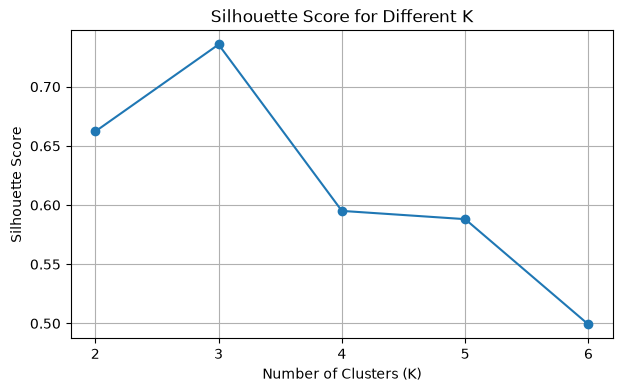

จำนวนกลุ่มที่เหมาะสมที่สุด K = 3
Silhouette Score = 0.7356847709879414


In [5]:
# แสดง Silhouette Score
plt.figure(figsize=(7, 4))
plt.plot(list(scores.keys()), list(scores.values()), marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")
plt.xticks(list(scores.keys()))
plt.grid(True)
plt.show()

best_k = max(scores, key=scores.get)
print("จำนวนกลุ่มที่เหมาะสมที่สุด K =", best_k)
print("Silhouette Score =", scores[best_k])

In [6]:
# สร้างโมเดล K-Means ด้วย K ที่ดีที่สุด
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
X["Cluster"] = kmeans.fit_predict(X_scaled)

X.head()


,Weight,Height,Cluster
0,67.062924,176.086355,0
1,68.804094,178.388669,0
2,60.930863,170.284496,2
3,59.733843,168.691992,2
4,65.431230,173.763679,0


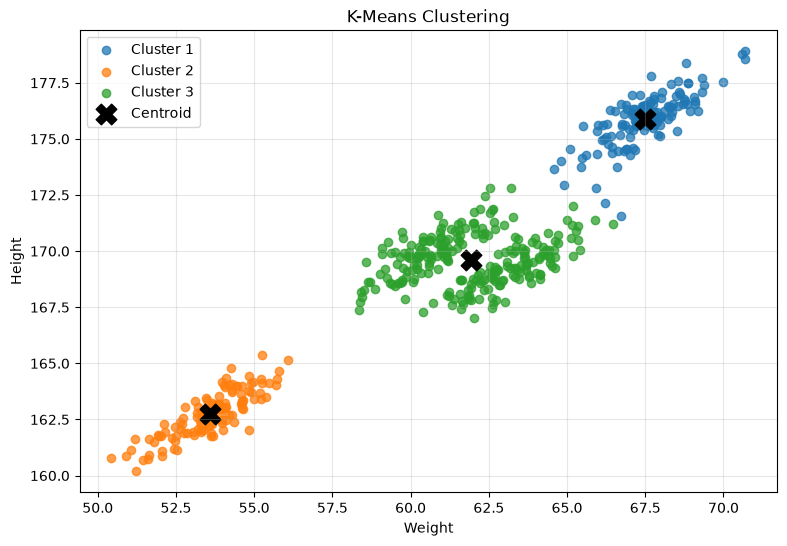

In [7]:
# Scatter Plot แสดงผลการจัดกลุ่ม
plt.figure(figsize=(9, 6))

for cluster in sorted(X["Cluster"].unique()):
    data_cluster = X[X["Cluster"] == cluster]
    plt.scatter(
        data_cluster["Weight"],
        data_cluster["Height"],
        label=f"Cluster {cluster + 1}",
        alpha=0.75
    )

# แสดงจุด Centroid ในสเกลเดิม
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=220,
    c="black",
    label="Centroid"
)

plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("K-Means Clustering")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
# สรุปจำนวนข้อมูลในแต่ละกลุ่ม
cluster_summary = X.groupby("Cluster").agg(
    Count=("Cluster", "size")
)

cluster_summary.index = cluster_summary.index + 1
cluster_summary.index.name = "Cluster"

cluster_summary

,Count
Cluster,
1,128
2,125
3,247
